  Patient_ID  Age  Gender  Department  Treatment_Cost  Stay_Days  Heart_Rate  \
0       P001   25    Male     General            5000          2          78   
1       P002   45  Female  Cardiology           25000          5          92   
2       P003   32    Male  Orthopedic           12000          3          84   
3       P004   60  Female  Cardiology           35000          8          98   
4       P005   28  Female     General            6000          2          76   
5       P006   55    Male   Neurology           30000          7          88   
6       P007   40  Female  Orthopedic           15000          4          82   
7       P008   67    Male  Cardiology           40000         10         102   
8       P009   35    Male     General            7000          2          80   
9       P010   50  Female   Neurology           28000          6          90   

            Result  
0        Recovered  
1        Recovered  
2        Recovered  
3  Under Treatment  
4        Recov

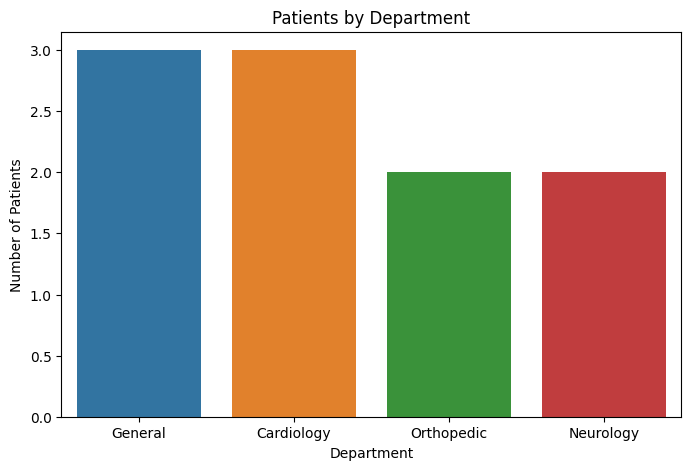

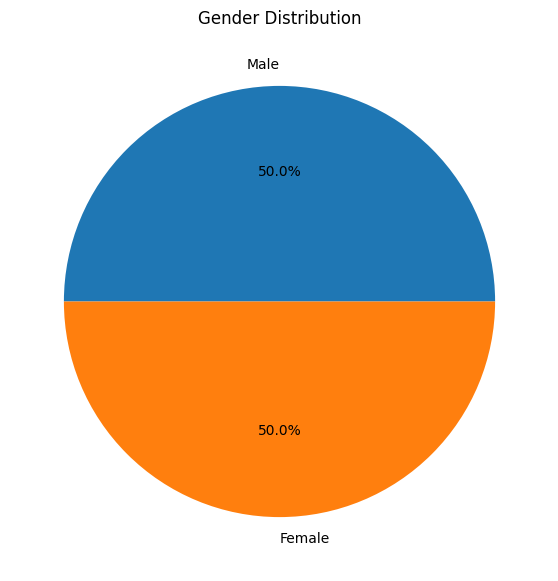

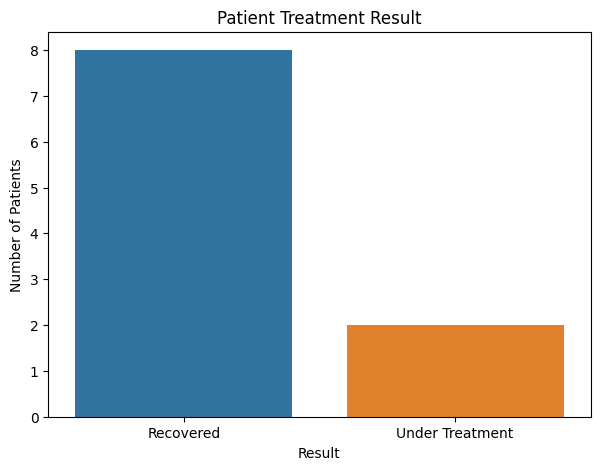

Age
0-18     0
19-30    2
31-45    4
46-60    3
61+      1
Name: count, dtype: int64


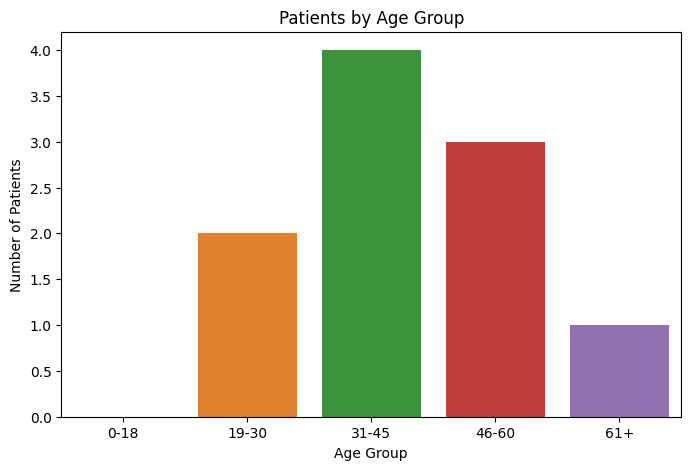

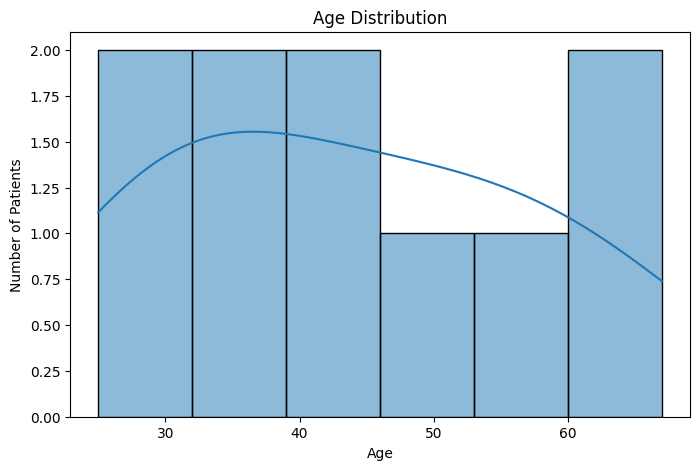

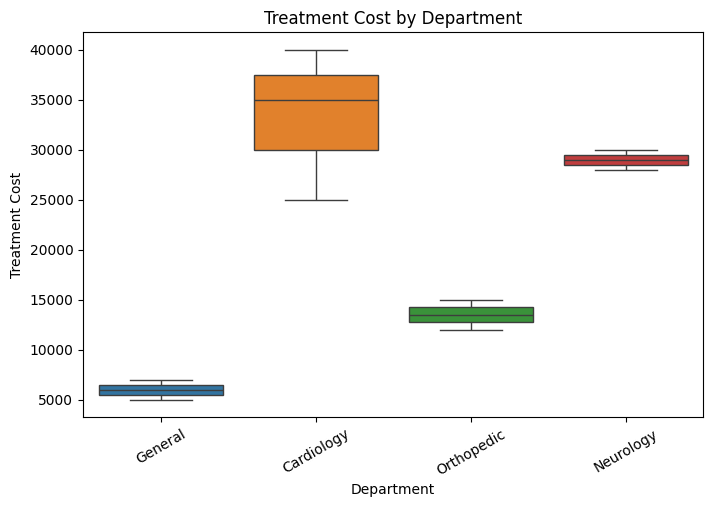

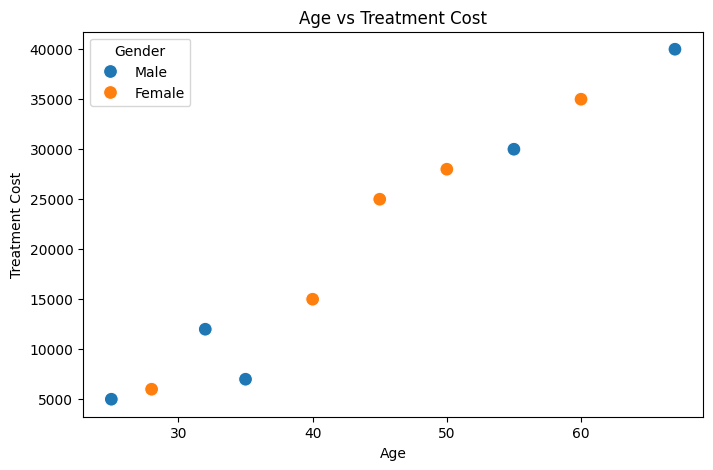

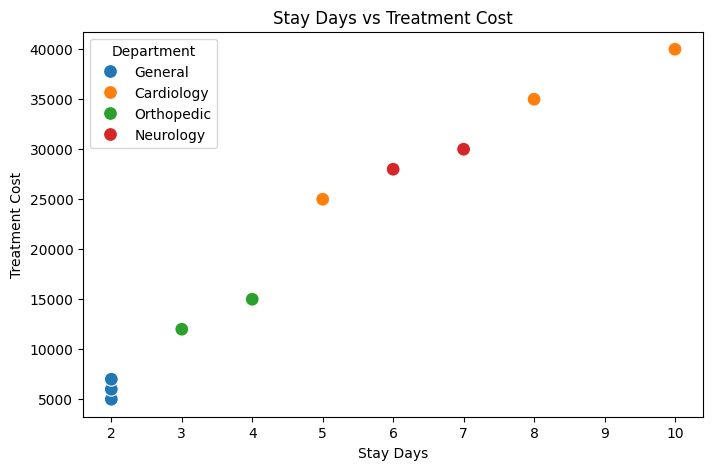

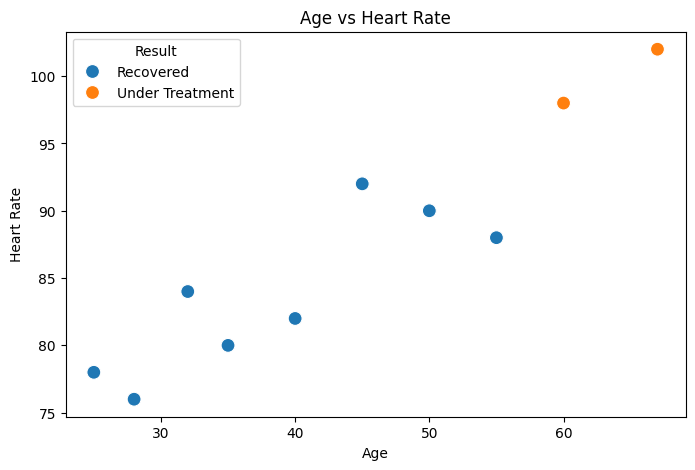

                     Age  Treatment_Cost  Stay_Days  Heart_Rate
Age             1.000000        0.979876   0.981667    0.932482
Treatment_Cost  0.979876        1.000000   0.984770    0.955998
Stay_Days       0.981667        0.984770   1.000000    0.943395
Heart_Rate      0.932482        0.955998   0.943395    1.000000


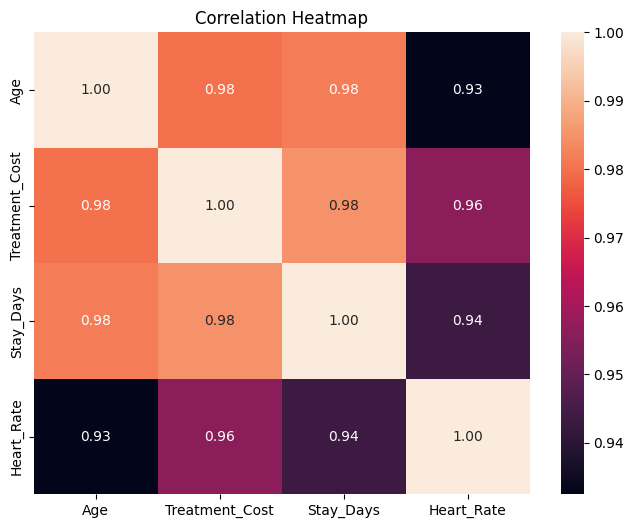

Patient_ID                   P008
Age                            67
Gender                       Male
Department             Cardiology
Treatment_Cost              40000
Stay_Days                      10
Heart_Rate                    102
Result            Under Treatment
Name: 7, dtype: object
Patient_ID             P001
Age                      25
Gender                 Male
Department          General
Treatment_Cost         5000
Stay_Days                 2
Heart_Rate               78
Result            Recovered
Name: 0, dtype: object
Patient_ID                   P008
Age                            67
Gender                       Male
Department             Cardiology
Treatment_Cost              40000
Stay_Days                      10
Heart_Rate                    102
Result            Under Treatment
Name: 7, dtype: object
Patient_ID                   P008
Age                            67
Gender                       Male
Department             Cardiology
Treatment_Cost             

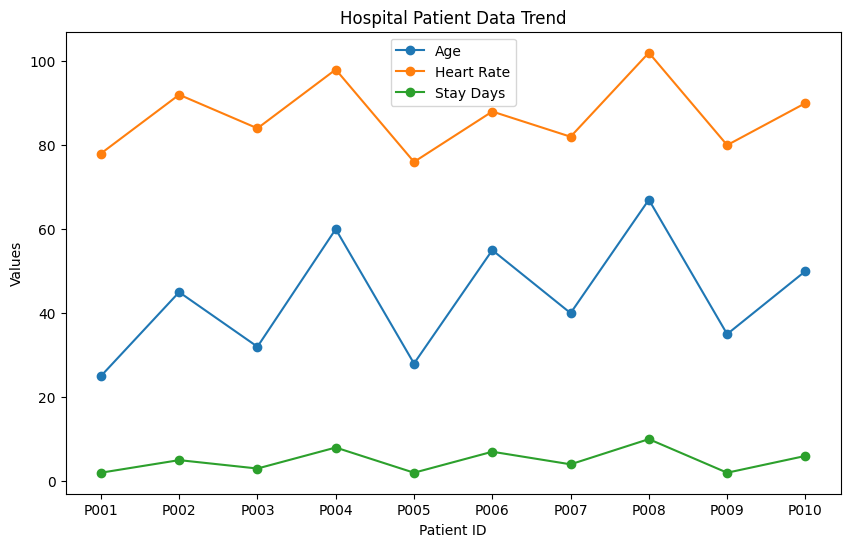

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_excel("hospital.xlsx")

print(df)

print(df.head())

print(df.head(3))

print(df.tail())

print(df.tail(3))

print(df.shape)

print(df.info())

print(df.dtypes)

print(df.describe())

print(df[["Age", "Treatment_Cost", "Stay_Days", "Heart_Rate"]].mean())

print(df[["Age", "Treatment_Cost", "Stay_Days", "Heart_Rate"]].max())

print(df[["Age", "Treatment_Cost", "Stay_Days", "Heart_Rate"]].min())

print(df["Department"].value_counts())

print(df["Gender"].value_counts())

print(df["Result"].value_counts())


department_count = df["Department"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=department_count.index,
    y=department_count.values,
    hue=department_count.index,
    legend=False
)

plt.title("Patients by Department")
plt.xlabel("Department")
plt.ylabel("Number of Patients")

plt.show()


gender_count = df["Gender"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()


result_count = df["Result"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=result_count.index,
    y=result_count.values,
    hue=result_count.index,
    legend=False
)

plt.title("Patient Treatment Result")
plt.xlabel("Result")
plt.ylabel("Number of Patients")

plt.show()


age_group = pd.cut(
    df["Age"],
    bins=[0, 18, 30, 45, 60, 100],
    labels=["0-18", "19-30", "31-45", "46-60", "61+"]
)

age_count = age_group.value_counts().sort_index()

print(age_count)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=age_count.index,
    y=age_count.values,
    hue=age_count.index,
    legend=False
)

plt.title("Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.show()


plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    bins=6,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()


plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Department",
    y="Treatment_Cost",
    hue="Department",
    legend=False
)

plt.title("Treatment Cost by Department")
plt.xlabel("Department")
plt.ylabel("Treatment Cost")

plt.xticks(rotation=30)

plt.show()


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Treatment_Cost",
    hue="Gender",
    s=100
)

plt.title("Age vs Treatment Cost")
plt.xlabel("Age")
plt.ylabel("Treatment Cost")

plt.show()


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Stay_Days",
    y="Treatment_Cost",
    hue="Department",
    s=100
)

plt.title("Stay Days vs Treatment Cost")
plt.xlabel("Stay Days")
plt.ylabel("Treatment Cost")

plt.show()


plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Age",
    y="Heart_Rate",
    hue="Result",
    s=100
)

plt.title("Age vs Heart Rate")
plt.xlabel("Age")
plt.ylabel("Heart Rate")

plt.show()


corr = df[
    ["Age", "Treatment_Cost", "Stay_Days", "Heart_Rate"]
].corr()

print(corr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()


print(df.loc[df["Treatment_Cost"].idxmax()])

print(df.loc[df["Treatment_Cost"].idxmin()])

print(df.loc[df["Stay_Days"].idxmax()])

print(df.loc[df["Heart_Rate"].idxmax()])


plt.figure(figsize=(10, 6))

plt.plot(
    df["Patient_ID"],
    df["Age"],
    marker="o",
    label="Age"
)

plt.plot(
    df["Patient_ID"],
    df["Heart_Rate"],
    marker="o",
    label="Heart Rate"
)

plt.plot(
    df["Patient_ID"],
    df["Stay_Days"],
    marker="o",
    label="Stay Days"
)

plt.title("Hospital Patient Data Trend")

plt.xlabel("Patient ID")

plt.ylabel("Values")

plt.legend()

plt.show()